# 01 — Data Understanding & Focused Visualization — Revised v5

**Competition metric:** Visualization and understanding of data (20%).

Notebook ini fokus pada pemahaman struktur dataset rantai pasok beras, parsing data multi-sheet menjadi format long table, audit coverage per aktor-wilayah, dan visualisasi EDA yang menonjolkan density, titik rawan, serta perbandingan input-output.

**Revisi v5:** parser diperkuat untuk menangani kasus `dmu` kosong tetapi baris biaya/output valid, terutama pada sheet Wholesaler Tasikmalaya. Baris seperti ini tidak lagi dibuang; `dmu` dibuat otomatis berdasarkan urutan data dalam aktor-wilayah dan ditandai dengan `dmu_auto_assigned=True`.


In [1]:
from pathlib import Path
import zipfile, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
PLOT_DIR = OUTPUT_DIR / 'plots'
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Visual theme
# ---------------------------------------------------------------------
plt.rcParams.update({
    'figure.figsize': (11, 6),
    'figure.dpi': 120,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 10,
    'axes.titlesize': 14,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'grid.alpha': 0.25,
    'legend.frameon': False,
})

COLORS = {
    'ink': '#1f2937',
    'muted': '#6b7280',
    'good': '#2a9d8f',
    'warn': '#e9c46a',
    'bad': '#e76f51',
    'blue': '#457b9d',
    'purple': '#7b2cbf',
    'gray': '#d1d5db'
}
ACTOR_COLORS = {
    'Farmer': '#2a9d8f',
    'Rice Miller': '#457b9d',
    'Middlemen': '#e9c46a',
    'Wholesaler': '#f4a261',
    'Retail': '#e76f51',
}

def rupiah_short(x, pos=None):
    if pd.isna(x):
        return ''
    x = float(x)
    ax = abs(x)
    if ax >= 1e9:
        return f'{x/1e9:.1f}B'
    if ax >= 1e6:
        return f'{x/1e6:.0f}M'
    if ax >= 1e3:
        return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

def savefig(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()

## 1. Load dataset

Dataset asli berbentuk ZIP berisi file Excel. Setiap sheet mewakili satu aktor supply chain, lalu setiap sheet berisi blok wilayah.

In [2]:
def find_dataset_zip():
    candidates = [
        DATA_RAW / 'Rice Supply Chain in West Java Province, Indonesia.zip',
        PROJECT_ROOT / 'Rice Supply Chain in West Java Province, Indonesia.zip',
        PROJECT_ROOT.parent / 'Rice Supply Chain in West Java Province, Indonesia.zip',
        Path('/mnt/data/Rice Supply Chain in West Java Province, Indonesia.zip'),
    ]
    for p in candidates:
        if p.exists():
            return p
    matches = list(PROJECT_ROOT.rglob('Rice Supply Chain in West Java Province, Indonesia.zip'))
    if matches:
        return matches[0]
    raise FileNotFoundError(
        'Dataset ZIP tidak ditemukan. Letakkan file "Rice Supply Chain in West Java Province, Indonesia.zip" '
        'di folder project, data/raw, atau folder yang sama dengan notebook.'
    )

zip_path = find_dataset_zip()
extract_dir = DATA_RAW / 'extracted_rice_supply_chain'
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

excel_files = list(extract_dir.rglob('*.xlsx'))
if not excel_files:
    raise FileNotFoundError('Tidak ada file .xlsx setelah ekstraksi ZIP.')
excel_path = excel_files[0]

xls = pd.ExcelFile(excel_path)
print('Dataset ZIP :', zip_path)
print('Excel file  :', excel_path)
print('Sheets      :', xls.sheet_names)

Dataset ZIP : c:\Users\USER\Documents\VSCODE\riceguard_notebooks\data\raw\Rice Supply Chain in West Java Province, Indonesia.zip
Excel file  : c:\Users\USER\Documents\VSCODE\riceguard_notebooks\data\raw\extracted_rice_supply_chain\Rice Supply Chain in West Java Province, Indonesia\Rice Supply Chain in West Java Province, Indonesia.xlsx
Sheets      : ['Farmer Data', 'Rice Miller Data', 'Middlemen Data', 'Wholesaler Data', 'Retail Data']


## 2. Parsing sheet menjadi format long table

Struktur sheet tidak langsung tabular penuh karena nama wilayah muncul sebagai baris pemisah, lalu header `dmu` diulang untuk setiap wilayah. Parser di bawah melakukan:

1. deteksi baris wilayah,
2. deteksi header per wilayah,
3. ekstraksi baris data,
4. konversi nama kolom menjadi snake_case,
5. audit baris dengan `dmu` kosong tetapi data biaya/output valid.

> **Important fix:** beberapa baris Wholesaler Tasikmalaya memiliki nilai biaya/output tetapi kolom `dmu` kosong. Karena baris tersebut tetap valid secara data, notebook ini tidak membuangnya. `dmu` dibuat otomatis per aktor-wilayah berdasarkan urutan baris agar seluruh observasi valid masuk ke analisis.


In [3]:

def slugify(x):
    raw = str(x).strip().lower()
    has_idr = 'idr' in raw
    has_kg = 'kg' in raw
    has_m2 = 'm2' in raw
    base = re.sub(r'\([^)]*\)', '', raw)  # remove unit in parentheses after detecting it
    base = re.sub(r'[^a-z0-9]+', '_', base)
    base = re.sub(r'_+', '_', base).strip('_')

    special = {
        'nilaiberashasilgiling': 'value_of_milled_rice_idr',
    }
    if base in special:
        return special[base]
    if base == 'total_rice_purchase' and has_kg:
        return 'total_rice_purchase_kg'
    if base == 'total_rice_purchase' and has_idr:
        return 'total_rice_purchase_value_idr'
    if base == 'amount_of_milled_rice' and has_kg:
        return 'amount_of_milled_rice'
    if base == 'land_area' and has_m2:
        return 'land_area'
    if has_idr and not base.endswith('_idr'):
        return base + '_idr'
    return base

SHEET_ACTOR = {
    'Farmer Data': 'Farmer',
    'Rice Miller Data': 'Rice Miller',
    'Middlemen Data': 'Middlemen',
    'Wholesaler Data': 'Wholesaler',
    'Retail Data': 'Retail',
}

def parse_sheet(sheet_name, actor):
    raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None)
    rows = []
    current_region = None
    current_header = None
    for raw_idx, row in raw.iterrows():
        values = row.tolist()
        non_null = [v for v in values if pd.notna(v)]
        if len(non_null) == 0:
            continue
        first = str(non_null[0]).strip()

        # Region row: only one non-null cell and not the repeated dmu header.
        if len(non_null) == 1 and first.lower() != 'dmu':
            current_region = first
            current_header = None
            continue

        # Header row: repeated inside every region.
        if first.lower() == 'dmu':
            current_header = [slugify(v) if pd.notna(v) else None for v in values]
            continue

        # Data row: must occur after a region and header. Some valid rows have blank dmu.
        if current_region is not None and current_header is not None:
            data_values = [v for h, v in zip(current_header, values) if h is not None and h != 'dmu']
            has_valid_payload = any(pd.notna(v) for v in data_values)
            if not has_valid_payload:
                continue

            rec = {'actor': actor, 'region': current_region, 'source_row': int(raw_idx)}
            for h, v in zip(current_header, values):
                if h is not None:
                    rec[h] = v
            rows.append(rec)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    if 'dmu' not in df.columns:
        df['dmu'] = np.nan

    df['dmu_original'] = df['dmu']
    df['dmu'] = pd.to_numeric(df['dmu'], errors='coerce')
    df['dmu_auto_assigned'] = df['dmu'].isna()

    # Assign missing dmu within each actor-region using source order.
    fixed_parts = []
    for (a, r), g in df.groupby(['actor', 'region'], sort=False):
        g = g.sort_values('source_row').copy()
        missing_mask = g['dmu'].isna()
        if missing_mask.any():
            existing = g.loc[~missing_mask, 'dmu'].dropna()
            start = int(existing.max()) + 1 if len(existing) else 1
            g.loc[missing_mask, 'dmu'] = np.arange(start, start + int(missing_mask.sum()))
        g['dmu'] = g['dmu'].astype(int)
        fixed_parts.append(g)
    df = pd.concat(fixed_parts, ignore_index=True, sort=False)

    return df

frames = []
parser_audit_rows = []
for sheet, actor in SHEET_ACTOR.items():
    part = parse_sheet(sheet, actor)
    frames.append(part)
    parser_audit_rows.append({
        'sheet': sheet,
        'actor': actor,
        'rows_parsed': int(part.shape[0]),
        'auto_dmu_assigned': int(part.get('dmu_auto_assigned', pd.Series(dtype=bool)).sum()) if not part.empty else 0,
        'columns': int(part.shape[1])
    })
    print(f'{actor:12s}: {part.shape[0]:4d} rows, auto dmu assigned = {parser_audit_rows[-1]["auto_dmu_assigned"]:3d}')

raw_long = pd.concat(frames, ignore_index=True, sort=False)
parser_audit = pd.DataFrame(parser_audit_rows)

print('\nConsolidated shape:', raw_long.shape)
print('Actor counts:')
display(raw_long['actor'].value_counts().rename_axis('actor').reset_index(name='n_rows'))
print('\nParser audit:')
display(parser_audit)
display(raw_long.head())


Farmer      :  400 rows, auto dmu assigned =   0
Rice Miller :  105 rows, auto dmu assigned =   0
Middlemen   :  104 rows, auto dmu assigned =   0
Wholesaler  :  104 rows, auto dmu assigned =  28
Retail      :  102 rows, auto dmu assigned =   0

Consolidated shape: (815, 27)
Actor counts:


,actor,n_rows
0,Farmer,400
1,Rice Miller,105
2,Middlemen,104
3,Wholesaler,104
4,Retail,102



Parser audit:


,sheet,actor,rows_parsed,auto_dmu_assigned,columns
0,Farmer Data,Farmer,400,0,14
1,Rice Miller Data,Rice Miller,105,0,13
2,Middlemen Data,Middlemen,104,0,14
3,Wholesaler Data,Wholesaler,104,28,12
4,Retail Data,Retail,102,0,12


,actor,region,source_row,dmu,land_area,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,dmu_original,dmu_auto_assigned,number_of_machines,value_of_milled_grains_idr,amount_of_milled_rice,supporting_equipment_cost_idr,value_of_milled_rice_idr,total_revenue_of_milling_machine_idr,total_rice_purchase_kg,total_rice_purchase_value_idr,building_rent_cost_idr,value_of_rice_sold_idr,total_precipitation,precipitation_quality,value_of_rice_purchase_idr
0,Farmer,Garut,2,1,"2,800.0000","4,900,000.0000","1,400,000.0000","644,000.0000","3,640,000.0000","364,000.0000","470,000.0000","16,200,000.0000",1.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Farmer,Garut,3,2,"1,400.0000","4,900,000.0000","500,000.0000","322,000.0000","1,820,000.0000","182,000.0000","540,000.0000","8,100,000.0000",2.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Farmer,Garut,4,3,"2,000.0000","2,000,000.0000","700,000.0000","200,000.0000","2,600,000.0000","260,000.0000","690,000.0000","14,850,000.0000",3.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Farmer,Garut,5,4,"1,000.0000","1,800,000.0000","800,000.0000","230,000.0000","1,300,000.0000","100,000.0000","340,000.0000","13,050,000.0000",4.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Farmer,Garut,6,5,800.0000,"1,520,000.0000","580,000.0000","184,000.0000","1,040,000.0000","104,000.0000","350,000.0000","10,200,000.0000",5.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Literature-aligned exploratory indicators

Notebook 01 hanya EDA, tetapi kita tetap membuat indikator awal yang akan dipakai untuk memahami masalah:

- `total_cost`: total biaya input/operasional,
- `output_value`: nilai output/penjualan,
- `margin`: output dikurangi biaya,
- `rc_ratio`: output dibagi biaya. Nilai di bawah 1 menunjukkan biaya lebih besar daripada output.

Indikator ini dihitung **per aktor** karena struktur input-output farmer, miller, middlemen, wholesaler, dan retail berbeda.

In [4]:
ACTOR_CONFIG = {
    'Farmer': {
        'cost_cols': ['land_lease_value_idr','labor_cost_idr','seed_purchase_value_idr','fertilizer_purchase_value_idr','pesticide_purchase_value_idr','equipment_rent_value_idr'],
        'output_cols': ['production_value_idr'],
        'dea_inputs': ['land_area','land_lease_value_idr','labor_cost_idr','seed_purchase_value_idr','fertilizer_purchase_value_idr','pesticide_purchase_value_idr','equipment_rent_value_idr'],
        'dea_outputs': ['production_value_idr'],
        'quantity_col': 'land_area',
        'asset_col': 'land_area'
    },
    'Rice Miller': {
        'cost_cols': ['value_of_milled_grains_idr','labor_cost_idr','supporting_equipment_cost_idr'],
        'output_cols': ['value_of_milled_rice_idr','total_revenue_of_milling_machine_idr'],
        'dea_inputs': ['number_of_machines','value_of_milled_grains_idr','labor_cost_idr','supporting_equipment_cost_idr'],
        'dea_outputs': ['value_of_milled_rice_idr','total_revenue_of_milling_machine_idr'],
        'quantity_col': 'amount_of_milled_rice',
        'asset_col': 'number_of_machines'
    },
    'Middlemen': {
        'cost_cols': ['total_rice_purchase_value_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],
        'output_cols': ['value_of_rice_sold_idr'],
        'dea_inputs': ['total_rice_purchase_kg','total_rice_purchase_value_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],
        'dea_outputs': ['value_of_rice_sold_idr'],
        'quantity_col': 'total_rice_purchase_kg',
        'asset_col': None
    },
    'Wholesaler': {
        'cost_cols': ['value_of_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],
        'output_cols': ['value_of_rice_sold_idr'],
        'dea_inputs': ['value_of_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],
        'dea_outputs': ['value_of_rice_sold_idr'],
        'quantity_col': None,
        'asset_col': None
    },
    'Retail': {
        'cost_cols': ['value_of_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],
        'output_cols': ['value_of_rice_sold_idr'],
        'dea_inputs': ['value_of_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],
        'dea_outputs': ['value_of_rice_sold_idr'],
        'quantity_col': None,
        'asset_col': None
    },
}

def coerce_numeric(df):
    out = df.copy()
    for c in out.columns:
        if c not in ['actor', 'region']:
            out[c] = pd.to_numeric(out[c], errors='coerce')
    return out

raw_long = coerce_numeric(raw_long)

def add_basic_features(df):
    parts = []
    for actor, g in df.groupby('actor', sort=False):
        cfg = ACTOR_CONFIG[actor]
        g = g.copy()
        cost_cols = [c for c in cfg['cost_cols'] if c in g.columns]
        output_cols = [c for c in cfg['output_cols'] if c in g.columns]
        g['total_cost'] = g[cost_cols].sum(axis=1, skipna=True)
        g['output_value'] = g[output_cols].sum(axis=1, skipna=True)
        g['margin'] = g['output_value'] - g['total_cost']
        g['rc_ratio'] = g['output_value'] / g['total_cost'].replace(0, np.nan)
        g['margin_ratio'] = g['margin'] / g['total_cost'].replace(0, np.nan)
        q = cfg.get('quantity_col')
        if q and q in g.columns:
            g['quantity_proxy'] = g[q]
            g['cost_per_quantity'] = g['total_cost'] / g[q].replace(0, np.nan)
        else:
            g['quantity_proxy'] = np.nan
            g['cost_per_quantity'] = np.nan
        parts.append(g)
    return pd.concat(parts, ignore_index=True, sort=False)

understanding_df = add_basic_features(raw_long)
summary = (
    understanding_df.groupby(['actor','region'])
    .agg(
        n_dmu=('dmu','count'),
        median_cost=('total_cost','median'),
        median_output=('output_value','median'),
        median_margin=('margin','median'),
        median_rc=('rc_ratio','median'),
        vulnerable_share=('rc_ratio', lambda s: np.mean(s < 1)),
    )
    .reset_index()
)

display(summary.head(10))

,actor,region,n_dmu,median_cost,median_output,median_margin,median_rc,vulnerable_share
0,Farmer,Garut,98,"7,641,100.0000","13,570,000.0000","6,111,000.0000",2.3967,0.2041
1,Farmer,Indramayu,62,"26,855,000.0000","47,650,000.0000","17,616,000.0000",1.7726,0.0806
2,Farmer,Karawang,53,"40,890,000.0000","81,600,000.0000","44,410,000.0000",2.0732,0.0943
3,Farmer,Subang,77,"13,035,000.0000","25,650,000.0000","13,120,000.0000",1.9662,0.0779
4,Farmer,Tasikmalaya,110,"6,713,450.0000","14,145,000.0000","7,013,500.0000",2.3789,0.0182
5,Middlemen,Garut,24,"40,650,000.0000","26,840,000.0000","-6,500,000.0000",0.7365,0.9167
6,Middlemen,Indramayu,16,"99,892,414.0000","88,000,000.0000","-6,617,415.2588",0.9196,0.5625
7,Middlemen,Karawang,14,"68,075,000.0000","66,500,000.0000","-1,525,000.0000",0.9836,0.5000
8,Middlemen,Subang,21,"115,400,000.0000","130,240,000.0000","14,840,000.0000",1.0841,0.4286
9,Middlemen,Tasikmalaya,29,"41,257,069.3597","33,440,000.0000","-7,685,346.7983",0.7716,0.7931


## 4. EDA visual 1 — Coverage heatmap

Visual ini menunjukkan apakah dataset seimbang antar aktor dan wilayah. Ini penting karena model pada notebook berikutnya harus sadar bahwa jumlah data per aktor tidak sama.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\01_coverage_heatmap.png


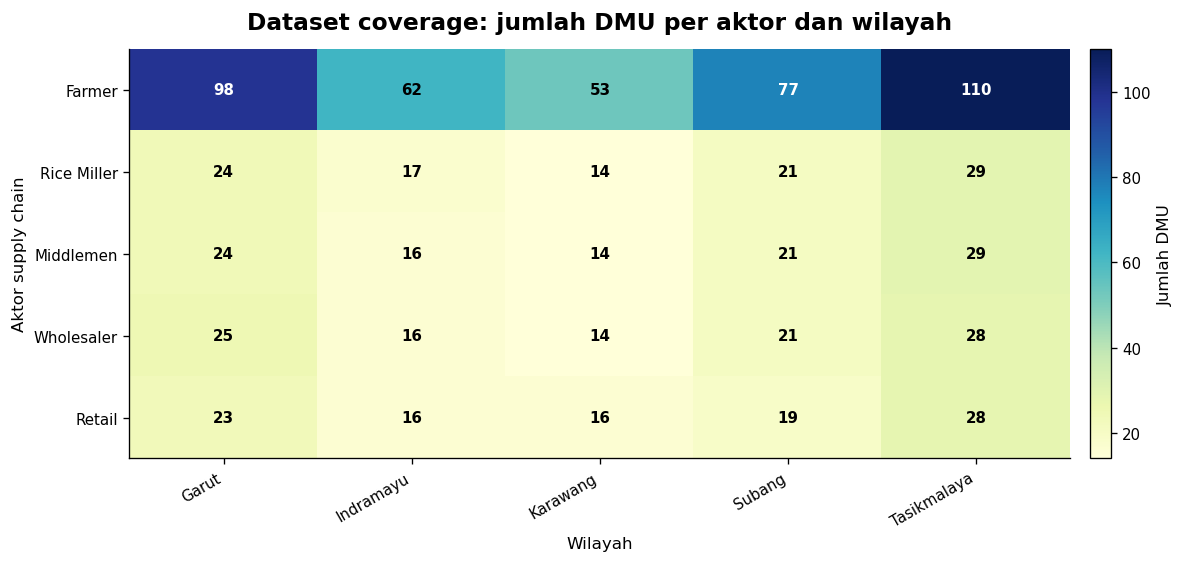

In [5]:
coverage = understanding_df.pivot_table(index='actor', columns='region', values='dmu', aggfunc='count', fill_value=0)
coverage = coverage.loc[[a for a in ACTOR_CONFIG.keys() if a in coverage.index]]

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(coverage.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(len(coverage.columns)), coverage.columns, rotation=30, ha='right')
ax.set_yticks(range(len(coverage.index)), coverage.index)
ax.set_title('Dataset coverage: jumlah DMU per aktor dan wilayah')
ax.set_xlabel('Wilayah')
ax.set_ylabel('Aktor supply chain')

for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]):
        val = int(coverage.iloc[i, j])
        ax.text(j, i, val, ha='center', va='center', fontsize=9, color='black' if val < coverage.values.max()*0.65 else 'white', fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Jumlah DMU')
savefig('01_coverage_heatmap.png')

## 5. EDA visual 2 — Density + points pada R/C ratio

Visual ini memperlihatkan **sebaran efisiensi finansial awal**. Garis vertikal `R/C = 1` menjadi titik fokus: kiri garis berarti biaya lebih besar daripada output.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\01_rc_ratio_density_points.png


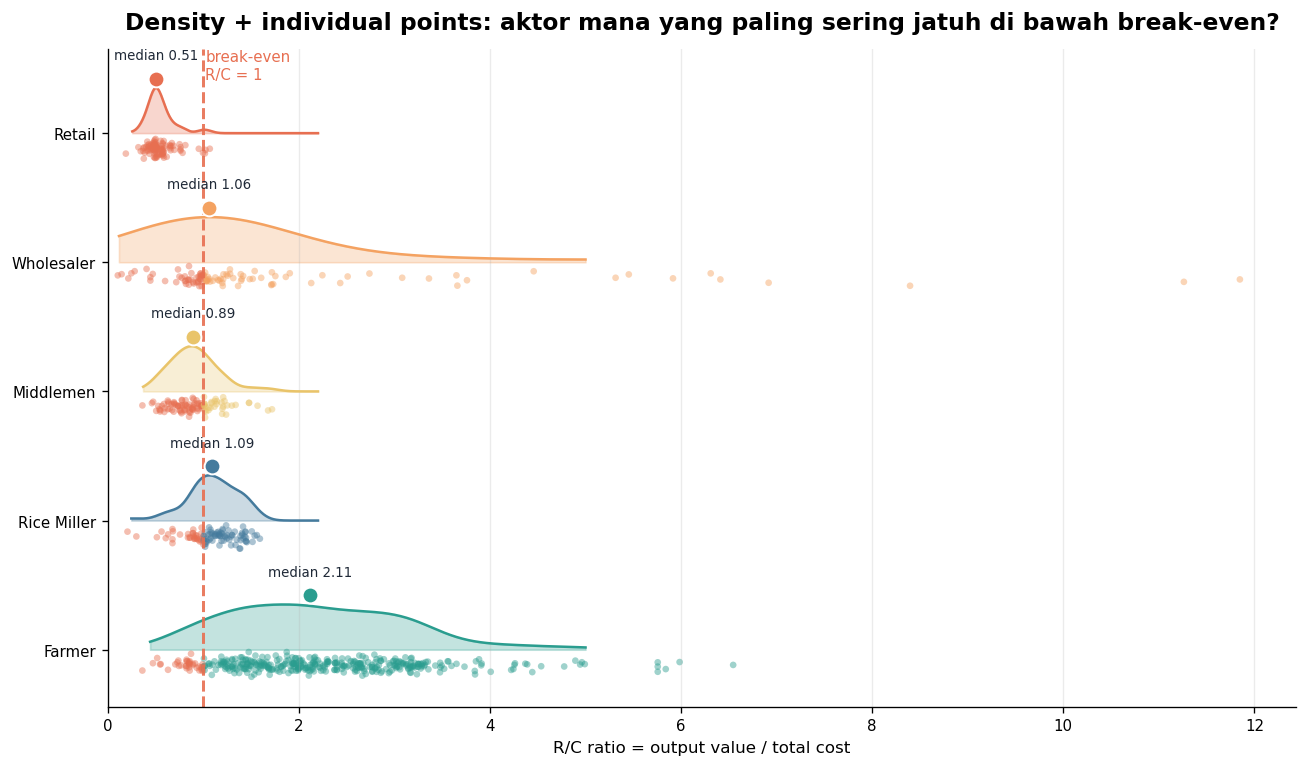

In [6]:
fig, ax = plt.subplots(figsize=(11, 6.5))
actors = [a for a in ACTOR_CONFIG.keys() if a in understanding_df['actor'].unique()]
y_positions = np.arange(len(actors))

# KDE density per actor, drawn horizontally as ridges
for y, actor in zip(y_positions, actors):
    vals = understanding_df.loc[understanding_df['actor'] == actor, 'rc_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
    vals = vals[(vals > 0) & (vals < vals.quantile(0.99) * 1.4)]
    color = ACTOR_COLORS.get(actor, COLORS['blue'])
    if len(vals) >= 5:
        try:
            from scipy.stats import gaussian_kde
            xmin = max(0, vals.quantile(0.01) * 0.8)
            xmax = min(max(2.2, vals.quantile(0.99) * 1.1), 5)
            grid = np.linspace(xmin, xmax, 220)
            kde = gaussian_kde(vals)
            dens = kde(grid)
            dens = dens / dens.max() * 0.35
            ax.fill_between(grid, y, y + dens, color=color, alpha=0.28)
            ax.plot(grid, y + dens, color=color, lw=1.5)
        except Exception:
            pass
    # jittered points
    rng = np.random.default_rng(42 + y)
    jitter = rng.normal(0, 0.035, len(vals))
    point_colors = np.where(vals < 1, COLORS['bad'], color)
    ax.scatter(vals, np.full(len(vals), y) - 0.12 + jitter, s=16, alpha=0.45, c=point_colors, edgecolors='none')
    median = vals.median()
    ax.scatter([median], [y + 0.42], s=90, color=color, edgecolor='white', linewidth=1.2, zorder=5)
    ax.text(median, y + 0.55, f'median {median:.2f}', ha='center', va='bottom', fontsize=8, color=COLORS['ink'])

ax.axvline(1, color=COLORS['bad'], linestyle='--', lw=1.8, alpha=0.9)
ax.text(1.02, len(actors)-0.35, 'break-even\nR/C = 1', color=COLORS['bad'], fontsize=9, ha='left', va='top')
ax.set_yticks(y_positions, actors)
ax.set_xlim(left=0)
ax.set_xlabel('R/C ratio = output value / total cost')
ax.set_title('Density + individual points: aktor mana yang paling sering jatuh di bawah break-even?')
ax.grid(axis='x')
savefig('01_rc_ratio_density_points.png')

## 6. EDA visual 3 — Share DMU vulnerable per aktor

Di sini fokusnya bukan jumlah data, melainkan **proporsi DMU dengan R/C ratio < 1**. Ini membantu menunjukkan bottleneck aktor rantai pasok.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\01_vulnerable_share_by_actor.png


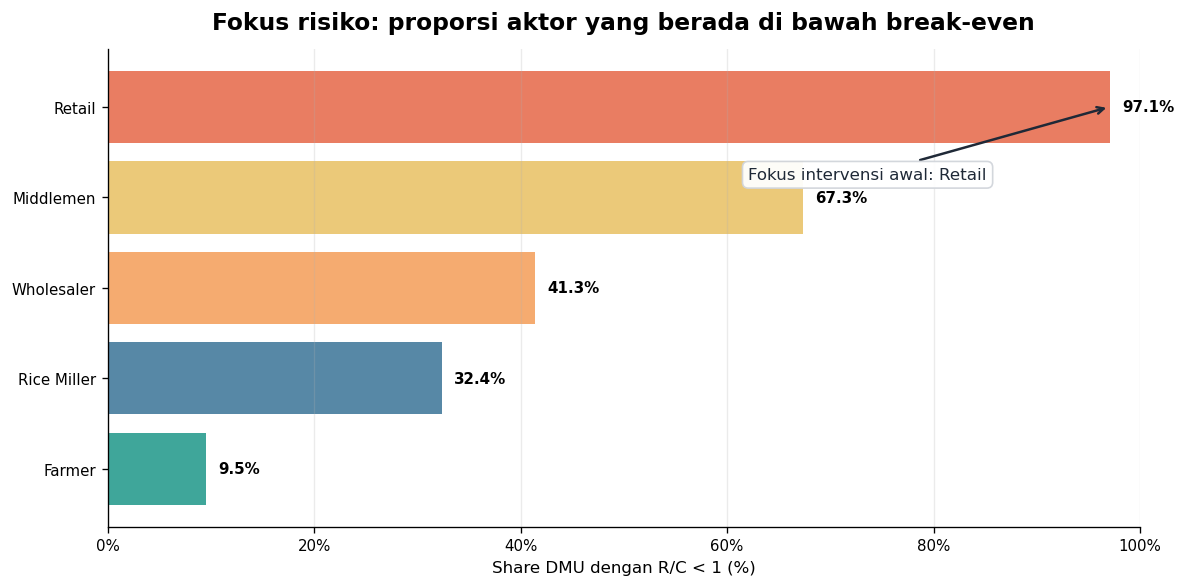

In [7]:
vuln = (
    understanding_df.groupby('actor')['rc_ratio']
    .apply(lambda s: np.mean(s < 1) * 100)
    .reindex(actors)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(vuln.index, vuln.values, color=[ACTOR_COLORS.get(a, COLORS['blue']) for a in vuln.index], alpha=0.9)
ax.set_xlim(0, 100)
ax.set_xlabel('Share DMU dengan R/C < 1 (%)')
ax.set_title('Fokus risiko: proporsi aktor yang berada di bawah break-even')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))
ax.grid(axis='x')
for bar, val in zip(bars, vuln.values):
    ax.text(val + 1.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# Focus annotation for highest vulnerable share
hi_actor = vuln.idxmax()
hi_val = vuln.max()
ax.annotate(
    f'Fokus intervensi awal: {hi_actor}',
    xy=(hi_val, list(vuln.index).index(hi_actor)),
    xytext=(max(55, hi_val-35), list(vuln.index).index(hi_actor)-0.8),
    arrowprops=dict(arrowstyle='->', lw=1.5, color=COLORS['ink']),
    fontsize=10,
    color=COLORS['ink'],
    bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=COLORS['gray'], alpha=0.95)
)
savefig('01_vulnerable_share_by_actor.png')

## 7. EDA visual 4 — Regional median R/C heatmap

Visual ini membantu melihat kombinasi **aktor-wilayah** yang relatif kuat atau lemah.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\01_regional_median_rc_heatmap.png


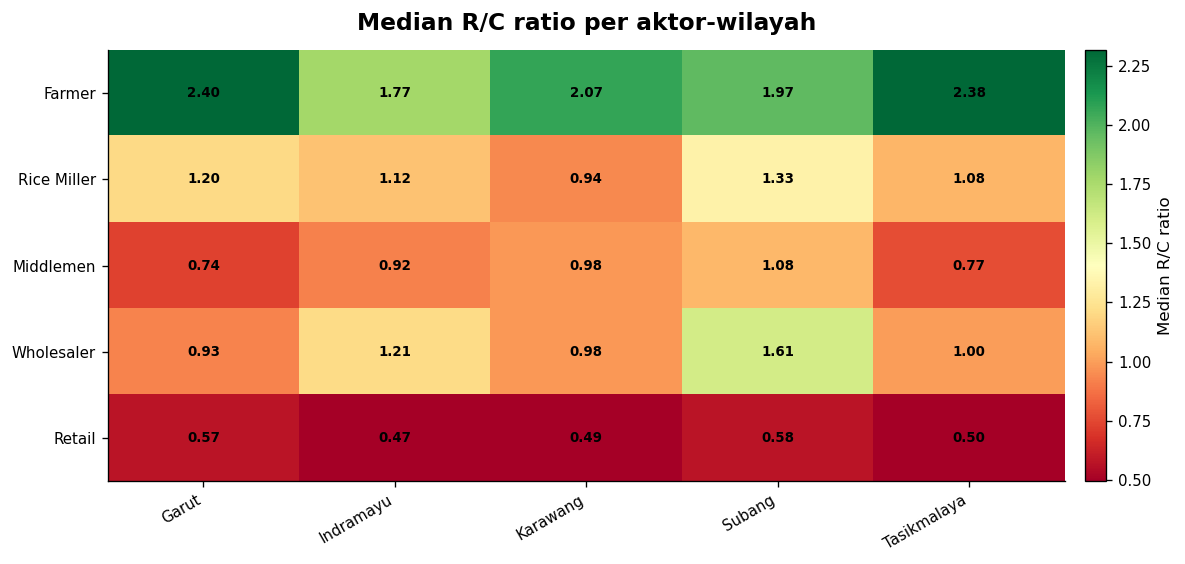

In [8]:
regional_rc = summary.pivot(index='actor', columns='region', values='median_rc').reindex(actors)

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(regional_rc.values, aspect='auto', cmap='RdYlGn', vmin=np.nanpercentile(regional_rc.values, 5), vmax=np.nanpercentile(regional_rc.values, 95))
ax.set_xticks(range(len(regional_rc.columns)), regional_rc.columns, rotation=30, ha='right')
ax.set_yticks(range(len(regional_rc.index)), regional_rc.index)
ax.set_title('Median R/C ratio per aktor-wilayah')

for i in range(regional_rc.shape[0]):
    for j in range(regional_rc.shape[1]):
        val = regional_rc.iloc[i, j]
        label = '' if pd.isna(val) else f'{val:.2f}'
        ax.text(j, i, label, ha='center', va='center', fontsize=8, color='black', fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Median R/C ratio')
savefig('01_regional_median_rc_heatmap.png')

## 8. EDA visual 5 — Cost structure by actor

Visual ini memperlihatkan biaya mana yang paling dominan pada tiap aktor. Ini penting karena fitur stress-test di Notebook 02 akan mensimulasikan kenaikan biaya.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\01_cost_structure_by_actor.png


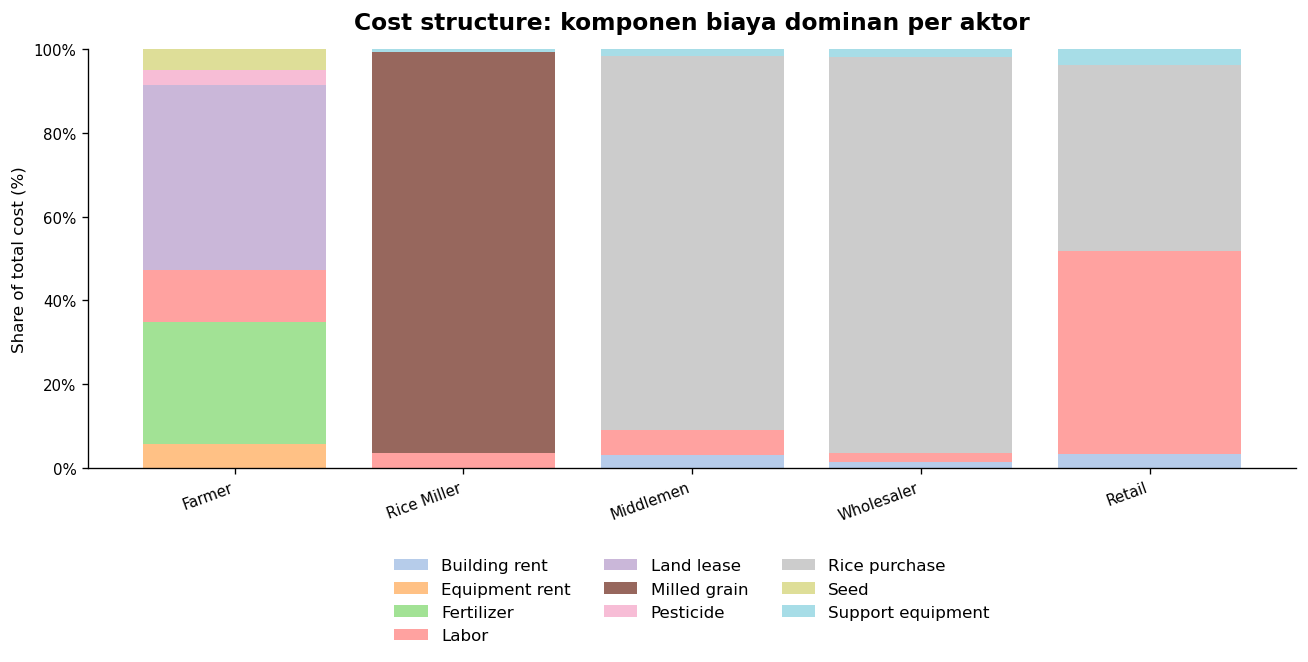

In [9]:
COST_LABELS = {
    'land_lease_value_idr': 'Land lease',
    'labor_cost_idr': 'Labor',
    'seed_purchase_value_idr': 'Seed',
    'fertilizer_purchase_value_idr': 'Fertilizer',
    'pesticide_purchase_value_idr': 'Pesticide',
    'equipment_rent_value_idr': 'Equipment rent',
    'value_of_milled_grains_idr': 'Milled grain',
    'supporting_equipment_cost_idr': 'Support equipment',
    'total_rice_purchase_value_idr': 'Rice purchase',
    'value_of_rice_purchase_idr': 'Rice purchase',
    'building_rent_cost_idr': 'Building rent',
}

rows = []
for actor, cfg in ACTOR_CONFIG.items():
    g = understanding_df[understanding_df['actor'] == actor]
    total = g['total_cost'].sum()
    for col in cfg['cost_cols']:
        if col in g.columns:
            rows.append({'actor': actor, 'component': COST_LABELS.get(col, col), 'share': g[col].sum() / total if total else np.nan})
cost_mix = pd.DataFrame(rows)
plot_mix = cost_mix.pivot_table(index='actor', columns='component', values='share', aggfunc='sum').fillna(0).reindex(actors)

fig, ax = plt.subplots(figsize=(11, 5.8))
bottom = np.zeros(len(plot_mix))
components = plot_mix.columns.tolist()
colors = plt.cm.tab20(np.linspace(0.05, 0.95, len(components)))
for comp, color in zip(components, colors):
    vals = plot_mix[comp].values * 100
    ax.bar(plot_mix.index, vals, bottom=bottom, label=comp, color=color, alpha=0.9)
    bottom += vals
ax.set_ylim(0, 100)
ax.set_ylabel('Share of total cost (%)')
ax.set_title('Cost structure: komponen biaya dominan per aktor')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))
ax.legend(ncol=3, bbox_to_anchor=(0.5, -0.18), loc='upper center')
plt.xticks(rotation=20, ha='right')
savefig('01_cost_structure_by_actor.png')

## 9. EDA visual 6 — Output vs cost, titik rawan difokuskan

Scatter ini memperlihatkan hubungan `total_cost` dan `output_value`. Garis diagonal adalah break-even. Titik di bawah garis berarti output lebih kecil dari biaya.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\01_output_vs_cost_focus_scatter.png


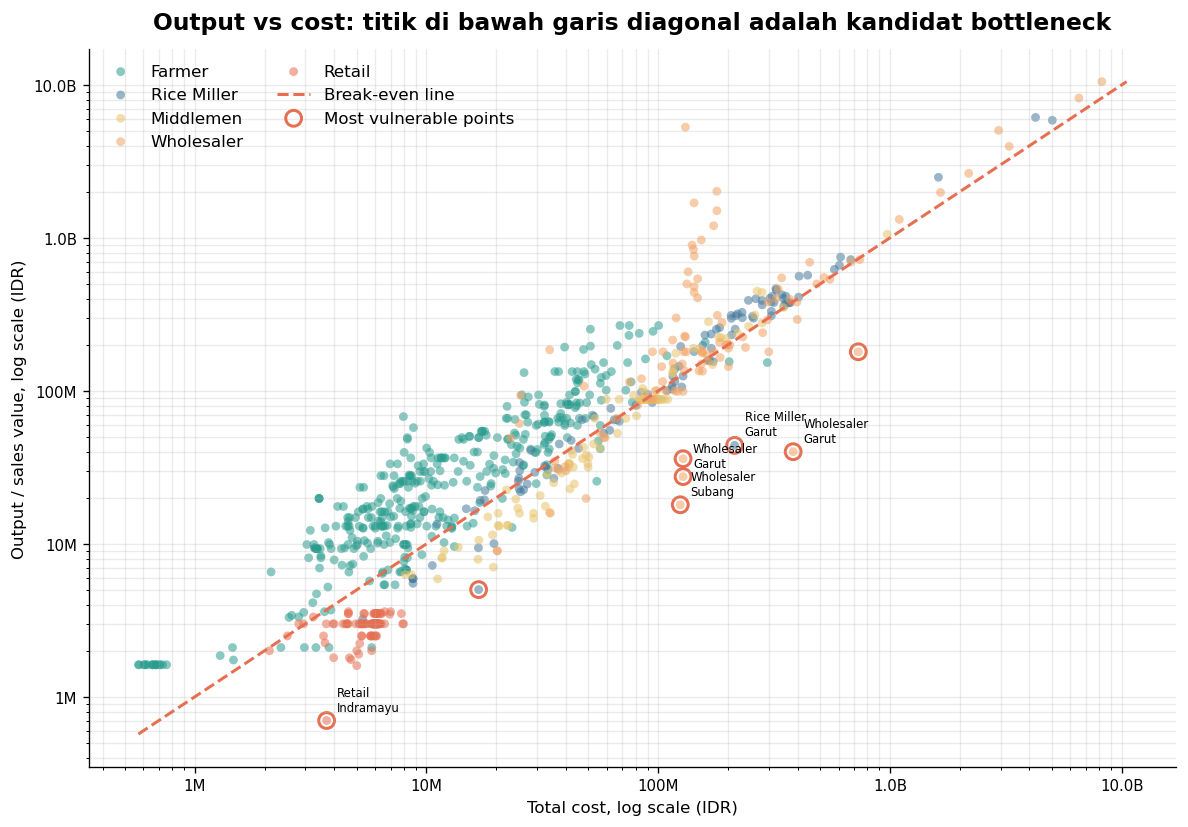

In [10]:
plot_df = understanding_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['total_cost','output_value','rc_ratio']).copy()
plot_df = plot_df[(plot_df['total_cost'] > 0) & (plot_df['output_value'] > 0)]

fig, ax = plt.subplots(figsize=(10, 7))
for actor in actors:
    g = plot_df[plot_df['actor'] == actor]
    ax.scatter(g['total_cost'], g['output_value'], s=28, alpha=0.55, label=actor, color=ACTOR_COLORS.get(actor, None), edgecolors='none')

minv = min(plot_df['total_cost'].min(), plot_df['output_value'].min())
maxv = max(plot_df['total_cost'].max(), plot_df['output_value'].max())
ax.plot([minv, maxv], [minv, maxv], linestyle='--', color=COLORS['bad'], lw=1.8, label='Break-even line')

# Highlight worst points by negative margin ratio
worst = plot_df.nsmallest(8, 'margin_ratio')
ax.scatter(worst['total_cost'], worst['output_value'], s=90, facecolors='none', edgecolors=COLORS['bad'], linewidths=1.8, label='Most vulnerable points')
for _, r in worst.head(5).iterrows():
    ax.annotate(f"{r['actor']}\n{r['region']}", xy=(r['total_cost'], r['output_value']), xytext=(6, 6), textcoords='offset points', fontsize=7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Total cost, log scale (IDR)')
ax.set_ylabel('Output / sales value, log scale (IDR)')
ax.set_title('Output vs cost: titik di bawah garis diagonal adalah kandidat bottleneck')
ax.xaxis.set_major_formatter(FuncFormatter(rupiah_short))
ax.yaxis.set_major_formatter(FuncFormatter(rupiah_short))
ax.legend(ncol=2, loc='upper left')
ax.grid(True, which='both')
savefig('01_output_vs_cost_focus_scatter.png')

## 10. Key EDA takeaways

Cell ini membuat ringkasan otomatis dari dataset, sehingga EDA tidak hanya menampilkan grafik tetapi juga menghasilkan insight yang dapat langsung dipakai di laporan.

Bagian ini juga membantu mengecek apakah jumlah DMU per aktor masuk akal setelah parser diperbaiki. Jika ada `dmu_auto_assigned=True`, artinya baris tersebut valid secara biaya/output tetapi tidak punya nomor DMU pada file asli, sehingga nomor DMU dibuat otomatis agar tidak kehilangan observasi.


In [11]:
key_actor_vuln = vuln.sort_values(ascending=False).reset_index()
best_region_actor = summary.sort_values('median_rc', ascending=False).head(5)
worst_region_actor = summary.sort_values('median_rc', ascending=True).head(5)

print('Jumlah DMU per aktor:')
display(understanding_df['actor'].value_counts().rename_axis('actor').reset_index(name='n_dmu'))

print('\nAktor dengan share vulnerable tertinggi (R/C < 1):')
display(key_actor_vuln.head())

print('\nTop 5 aktor-wilayah berdasarkan median R/C:')
display(best_region_actor[['actor','region','n_dmu','median_rc','vulnerable_share']])

print('\nBottom 5 aktor-wilayah berdasarkan median R/C:')
display(worst_region_actor[['actor','region','n_dmu','median_rc','vulnerable_share']])

Jumlah DMU per aktor:


,actor,n_dmu
0,Farmer,400
1,Rice Miller,105
2,Middlemen,104
3,Wholesaler,104
4,Retail,102



Aktor dengan share vulnerable tertinggi (R/C < 1):


,actor,rc_ratio
0,Retail,97.0588
1,Middlemen,67.3077
2,Wholesaler,41.3462
3,Rice Miller,32.3810
4,Farmer,9.5000



Top 5 aktor-wilayah berdasarkan median R/C:


,actor,region,n_dmu,median_rc,vulnerable_share
0,Farmer,Garut,98,2.3967,0.2041
4,Farmer,Tasikmalaya,110,2.3789,0.0182
2,Farmer,Karawang,53,2.0732,0.0943
3,Farmer,Subang,77,1.9662,0.0779
1,Farmer,Indramayu,62,1.7726,0.0806



Bottom 5 aktor-wilayah berdasarkan median R/C:


,actor,region,n_dmu,median_rc,vulnerable_share
11,Retail,Indramayu,16,0.4729,1.0000
12,Retail,Karawang,16,0.4942,1.0000
14,Retail,Tasikmalaya,28,0.4956,1.0000
10,Retail,Garut,23,0.5738,0.9130
13,Retail,Subang,19,0.5769,0.9474


## 11. Save outputs for Notebook 02

Notebook 02 akan memakai file berikut:

- `outputs/01_consolidated_raw.csv`
- `outputs/01_summary_by_actor_region.csv`
- `outputs/01_actor_config.json`

In [12]:
understanding_df.to_csv(OUTPUT_DIR / '01_consolidated_raw.csv', index=False)
summary.to_csv(OUTPUT_DIR / '01_summary_by_actor_region.csv', index=False)
parser_audit.to_csv(OUTPUT_DIR / '01_parser_audit.csv', index=False)
with open(OUTPUT_DIR / '01_actor_config.json', 'w', encoding='utf-8') as f:
    json.dump(ACTOR_CONFIG, f, indent=2)

metadata = {
    'notebook': '01_data_understanding_visualization_REVISED_v5',
    'n_rows': int(understanding_df.shape[0]),
    'n_columns': int(understanding_df.shape[1]),
    'actors': sorted(understanding_df['actor'].dropna().unique().tolist()),
    'regions': sorted(understanding_df['region'].dropna().unique().tolist()),
    'actor_counts': understanding_df['actor'].value_counts().astype(int).to_dict(),
    'auto_dmu_assigned_total': int(understanding_df.get('dmu_auto_assigned', pd.Series(dtype=bool)).sum()),
    'parser_note': 'Rows with valid payload but blank dmu are retained and assigned sequential dmu within actor-region.',
    'generated_outputs': [
        '01_consolidated_raw.csv',
        '01_summary_by_actor_region.csv',
        '01_parser_audit.csv',
        '01_actor_config.json'
    ]
}
with open(OUTPUT_DIR / '01_eda_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved Notebook 01 outputs:')
for p in sorted(OUTPUT_DIR.glob('01_*')):
    print('-', p)


Saved Notebook 01 outputs:
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\01_actor_config.json
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\01_consolidated_raw.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\01_eda_metadata.json
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\01_parser_audit.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\01_summary_by_actor_region.csv
